# Step 6 — Deep Learning Signal Peptide Classifier
**LB2 Project · Group 7 · Signal Peptide Prediction**

### Objective
Train a **deep learning classifier** for signal peptide detection using
**ESM-2 embeddings** of the **N-terminal region** of each protein sequence.

### Pipeline
1. Load the predefined training/benchmark splits and restrict sequences to the **filtered non-redundant accession set**
2. Extract the **N-terminal 150 aa** from each sequence
3. Compute **ESM-2 embeddings** for each truncated sequence
4. Train a **1D CNN + bidirectional LSTM** model on the embedded sequences
5. Perform **5-fold cross-validation** using the provided fold assignments:
   - train on 4 folds
   - evaluate on the held-out fold
   - monitor **validation MCC**
   - apply **early stopping** and **ReduceLROnPlateau**
6. Retrain the final model on the **full training set** using the average best epoch from cross-validation
7. Evaluate once on the **held-out benchmark set**

### Model architecture
| Component | Description |
|---|---|
| Input | ESM-2 embeddings of N-terminal 150 aa (`shape = (B, 150, 480)`) |
| Convolutional encoder | Three 1D convolutional blocks with ReLU, BatchNorm, and MaxPool |
| Sequence model | 2-layer bidirectional LSTM (`hidden_size = 128`) |
| Classifier | Dropout → Linear → ReLU → Dropout → Linear |
| Output | Single logit → sigmoid probability for **SP+** |

### Input files
- `training_with_folds.tsv`
- `benchmarking_set.tsv`
- `filtered_positive.tsv`
- `filtered_negative.tsv`
- `positive.fasta`
- `negative.fasta`

### Output files
- `cnn_signal_peptide_model.pt`
- `cnn_cv_results.tsv`
- `cnn_model_comparison.tsv`
- `figures/cnn_*.pdf/.png` — training curves, confusion matrix, PR/ROC curves, and related benchmark figures
- Console summary: cross-validation metrics + benchmark metrics

**Key note**: This notebook uses **ESM-2 embeddings**, not one-hot encoding. The one-hot encoding cell is retained only for reference and is not used in the final model.

---
## Cell 1 — Set data directory and import libraries

Set `DATA_DIR` to the folder containing your `.tsv` and `.fasta` input files before running any other cell. All subsequent cells resolve file paths relative to this variable.

```
DATA_DIR = "."   # e.g. "/content/drive/MyDrive/lb2_data"
```

> **Note:** If running in Google Colab with files uploaded directly, leave this as `"."`. If files are in Google Drive, mount the drive first and set the full path accordingly.

This cell also imports all required libraries (`torch`, `biopython`, `sklearn`, `pandas`, `numpy`, `matplotlib`, `seaborn`) and creates the `figures/` output directory. Missing packages will raise an informative error with install instructions.

In [1]:
# ──────────────────────────────────────────────────────────────────
# DATA DIRECTORY — set this to the folder containing your .tsv and
# .fasta files before running the notebook.
# ──────────────────────────────────────────────────────────────────
DATA_DIR = "."   # e.g. "/home/user/lb2_data" or "/scratch/group7"

import os
import sys
import subprocess
import random
import numpy as np
import pandas as pd
from Bio import SeqIO

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display   # safe import for all Jupyter environments

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except ModuleNotFoundError:
    print("PyTorch not found. Please install it in your environment:")
    print("  pip install torch torchvision torchaudio")
    print("  or follow https://pytorch.org/get-started/locally/")
    raise

try:
    from Bio import SeqIO
except ModuleNotFoundError:
    print("Biopython not found. Install with: pip install biopython")
    raise

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve
)

os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)
print("Libraries loaded.")
print(f"DATA_DIR = '{DATA_DIR}'  ← update this if your files are elsewhere")


Libraries loaded.
DATA_DIR = '.'  ← update this if your files are elsewhere


---
## Cell 2 — Reproducibility and device setup

Fix all random seeds so every run produces identical results.
Uses GPU automatically if available (CUDA), otherwise CPU.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cpu


In [3]:
# NOTE: Run Cell 2 (seeds + DEVICE) before this cell.
# === ESM-2 Embeddings Setup ===
# fair-esm must be installed in your environment before running:
#   pip install fair-esm
try:
    import esm
except ModuleNotFoundError:
    print("fair-esm not found. Install with: pip install fair-esm")
    raise

import torch

print("Loading ESM-2 (35M) model...")
esm_model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()
esm_model = esm_model.eval().to(DEVICE)
batch_converter = alphabet.get_batch_converter()
print("ESM-2 loaded successfully! Embedding dim = 480")


Loading ESM-2 (35M) model...
ESM-2 loaded successfully! Embedding dim = 480


---
## Cell 3 — Global hyperparameters
All tunable parameters are defined here in one place for easy modification.

**Current configuration**
- **Input representation:** precomputed **ESM-2 embeddings**
- **Sequence length:** **N-terminal 150 aa**
- **Model:** **CNN + BiLSTM**
- **Training:** weighted BCE loss, early stopping on validation MCC, and LR reduction on validation-loss plateau
---

In [4]:
# --- ESM-2 settings ---
MAX_LEN = 150                    # increased slightly for ESM
ESM_MODEL_NAME = "esm2_t12_35M_UR50D"
ESM_DIM = 480
# --- Training ---
BATCH_SIZE  = 32
LR          = 1e-3
MAX_EPOCHS  = 30   # increased from 12; early stopping prevents overfitting
PATIENCE    = 5    # early stopping patience (epochs without MCC improvement)
LR_PATIENCE = 3    # ReduceLROnPlateau patience
LR_FACTOR   = 0.5  # multiply LR by this when plateau detected

# --- Model ---
DROPOUT = 0.3

print(f'MAX_LEN    : {MAX_LEN}')
print(f'MAX_EPOCHS : {MAX_EPOCHS} (with early stopping, patience={PATIENCE})')
print(f'Batch size : {BATCH_SIZE}')
print(f'LR         : {LR} (ReduceLROnPlateau, factor={LR_FACTOR}, patience={LR_PATIENCE})')

MAX_LEN    : 150
MAX_EPOCHS : 30 (with early stopping, patience=5)
Batch size : 32
LR         : 0.001 (ReduceLROnPlateau, factor=0.5, patience=3)


---
## Cell 4 — Load filtered metadata and sequences

Load training and benchmark TSV files, then restrict sequences to the
**filtered non-redundant accession set** from Step 2 (`filtered_positive.tsv` / `filtered_negative.tsv`).
Only accessions present in those files are kept, ensuring consistency with Steps 4 and 5.


In [6]:
def extract_accession(record):
    """Extract UniProt accession from FASTA header (handles sp|ACC|NAME and plain ACC formats)."""
    rid = record.id.strip()
    if '|' in rid:
        parts = rid.split("|")
        if len(parts) >= 2:
            return parts[1]
    return rid

# Load metadata
train_df = pd.read_csv(os.path.join(DATA_DIR, "../2- Data_Prepration/training_with_folds.tsv"), sep="\t")
bench_df = pd.read_csv(os.path.join(DATA_DIR, "../2- Data_Prepration/benchmarking_set.tsv"), sep="\t")

# Load filtered accession sets from Step 2 (clustered representatives only)
df_fpos = pd.read_csv(os.path.join(DATA_DIR, '../2- Data_Prepration/filtered_positive.tsv'), sep='\t')
df_fneg = pd.read_csv(os.path.join(DATA_DIR, '../2- Data_Prepration/filtered_negative.tsv'), sep='\t')
filtered_accessions = set(df_fpos['Accession']).union(set(df_fneg['Accession']))

print(f'Filtered accessions (Step 2 representatives): {len(filtered_accessions):,}')

# Load sequences — only keep accessions present in the filtered sets
seq_map = {}
for fasta_file in [os.path.join(DATA_DIR, '../1- Data_Collection/positive.fasta'), os.path.join(DATA_DIR, '../1- Data_Collection/negative.fasta')]:
    for rec in SeqIO.parse(fasta_file, 'fasta'):
        acc = extract_accession(rec)
        if acc in filtered_accessions:
            seq_map[acc] = str(rec.seq)

print(f'Sequences loaded from filtered set: {len(seq_map):,}')

# Attach sequences
train_df['Accession'] = train_df['Accession'].astype(str).str.strip()
bench_df['Accession'] = bench_df['Accession'].astype(str).str.strip()
train_df['sequence']  = train_df['Accession'].map(seq_map)
bench_df['sequence']  = bench_df['Accession'].map(seq_map)

missing_train = train_df['sequence'].isna().sum()
missing_bench = bench_df['sequence'].isna().sum()
assert missing_train == 0, f'{missing_train} training sequences not found in filtered FASTA'
assert missing_bench == 0, f'{missing_bench} benchmark sequences not found in filtered FASTA'

print(f'Training  : {len(train_df):,} | pos={(train_df.label==1).sum()} | neg={(train_df.label==0).sum()}')
print(f'Benchmark : {len(bench_df):,} | pos={(bench_df.label==1).sum()} | neg={(bench_df.label==0).sum()}')
print(f'Folds     : {sorted(train_df["fold"].unique())}')
print('All sequences matched. ✓')

Filtered accessions (Step 2 representatives): 10,027
Sequences loaded from filtered set: 10,027
Training  : 8,021 | pos=874 | neg=7147
Benchmark : 2,006 | pos=219 | neg=1787
Folds     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
All sequences matched. ✓


---
## Cell 5 — Sequence encoding functions (legacy / unused)

> **Note:** These one-hot encoding functions were part of the original baseline.
> The current pipeline uses ESM-2 embeddings instead. These functions are kept
> for reference but are not called anywhere in the notebook.


In [7]:
AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}
N_AA = len(AA_ORDER)  # 20

def clean_sequence(seq):
    """Uppercase and replace non-standard AAs with X (will be encoded as zero vector)."""
    seq = seq.upper()
    return ''.join([aa if aa in AA_TO_IDX else 'X' for aa in seq])

def pad_or_truncate(seq, max_len=MAX_LEN):
    """Truncate to max_len or pad with X to reach max_len."""
    seq = clean_sequence(seq)[:max_len]
    return seq + 'X' * (max_len - len(seq))

def one_hot_encode(seq, max_len=MAX_LEN):
    """One-hot encode sequence → numpy array of shape (max_len, 20)."""
    seq = pad_or_truncate(seq, max_len)
    arr = np.zeros((max_len, N_AA), dtype=np.float32)
    for i, aa in enumerate(seq):
        if aa in AA_TO_IDX:
            arr[i, AA_TO_IDX[aa]] = 1.0
    return arr

# NOTE: Functions above are legacy/unused — ESM-2 embeddings are used instead.
# To test manually: sample = one_hot_encode('MKLVVVGAGGVGKS'); print(sample.shape)

---
## Cell 6 — PyTorch Dataset
Wrap the DataFrame in a PyTorch Dataset so it can be used with `DataLoader`.

Each item is a tuple of:
- `embedding_tensor`: shape `(MAX_LEN, ESM_DIM)` using precomputed **ESM-2 embeddings**
- `label_tensor`: binary label (`0` for SP−, `1` for SP+)

This dataset does **not** use one-hot encoding.
---

In [8]:
class ESMSignalPeptideDataset(Dataset):
    """Uses pre-computed ESM-2 embeddings (super fast)"""
    def __init__(self, df, max_len=150):
        self.embeddings = df['embedding'].tolist()
        self.labels     = df['label'].values.astype(np.float32)
        self.max_len    = max_len

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        emb   = self.embeddings[idx].float()   # ensure float32 regardless of ESM output dtype
        label = self.labels[idx]
        return emb.clone(), torch.tensor(label, dtype=torch.float32)

In [9]:
# Sequences are already attached to train_df['sequence'] from Cell 4 above.
# This cell is kept as a checkpoint to confirm the column exists before ESM pre-computation.

assert 'sequence' in train_df.columns, "'sequence' column missing — re-run the data loading cell (Cell 4)"
assert 'sequence' in bench_df.columns, "'sequence' column missing from bench_df — re-run the data loading cell (Cell 4)"
print(f"✅ train_df['sequence']: {train_df['sequence'].notna().sum():,} sequences ready")
print(f"✅ bench_df['sequence']: {bench_df['sequence'].notna().sum():,} sequences ready")


✅ train_df['sequence']: 8,021 sequences ready
✅ bench_df['sequence']: 2,006 sequences ready


In [10]:
# === PRE-COMPUTE ESM-2 EMBEDDINGS FOR TRAINING SET (batched for speed) ===
print("Pre-computing ESM-2 embeddings for training set...")

EMBED_BATCH = 16   # sequences per ESM batch — reduce if you hit OOM on CPU
embedding_dict = {}
accessions = train_df['Accession'].tolist()
sequences  = [row[:MAX_LEN] for row in train_df['sequence'].tolist()]

for start in range(0, len(sequences), EMBED_BATCH):
    batch_acc  = accessions[start : start + EMBED_BATCH]
    batch_seqs = sequences [start : start + EMBED_BATCH]
    data = [(acc, seq) for acc, seq in zip(batch_acc, batch_seqs)]

    _, _, batch_tokens = batch_converter(data)
    with torch.no_grad():
        results = esm_model(batch_tokens.to(DEVICE), repr_layers=[12])

    for i, acc in enumerate(batch_acc):
        emb = results["representations"][12][i, 1:-1, :].cpu()  # remove <cls>/<eos>
        if emb.shape[0] < MAX_LEN:
            pad = torch.zeros(MAX_LEN - emb.shape[0], ESM_DIM)
            emb = torch.cat([emb, pad], dim=0)
        else:
            emb = emb[:MAX_LEN]
        embedding_dict[acc] = emb

    if (start // EMBED_BATCH) % 10 == 0:
        print(f"  {min(start + EMBED_BATCH, len(sequences)):,} / {len(sequences):,} done...")

train_df['embedding'] = train_df['Accession'].map(embedding_dict)
assert train_df['embedding'].isna().sum() == 0, "Some training embeddings are missing!"
print(f"✅ Pre-computed embeddings for {len(train_df):,} training proteins. Ready for fast training!")


Pre-computing ESM-2 embeddings for training set...
  16 / 8,021 done...
  176 / 8,021 done...
  336 / 8,021 done...
  496 / 8,021 done...
  656 / 8,021 done...
  816 / 8,021 done...
  976 / 8,021 done...
  1,136 / 8,021 done...
  1,296 / 8,021 done...
  1,456 / 8,021 done...
  1,616 / 8,021 done...
  1,776 / 8,021 done...
  1,936 / 8,021 done...
  2,096 / 8,021 done...
  2,256 / 8,021 done...
  2,416 / 8,021 done...
  2,576 / 8,021 done...
  2,736 / 8,021 done...
  2,896 / 8,021 done...
  3,056 / 8,021 done...
  3,216 / 8,021 done...
  3,376 / 8,021 done...
  3,536 / 8,021 done...
  3,696 / 8,021 done...
  3,856 / 8,021 done...
  4,016 / 8,021 done...
  4,176 / 8,021 done...
  4,336 / 8,021 done...
  4,496 / 8,021 done...
  4,656 / 8,021 done...
  4,816 / 8,021 done...
  4,976 / 8,021 done...
  5,136 / 8,021 done...
  5,296 / 8,021 done...
  5,456 / 8,021 done...
  5,616 / 8,021 done...
  5,776 / 8,021 done...
  5,936 / 8,021 done...
  6,096 / 8,021 done...
  6,256 / 8,021 done...
  6,

---
## Cell 7 — CNN + BiLSTM model architecture
Three convolutional blocks first extract local sequence motifs from the ESM-2 embedding sequence.
A 2-layer bidirectional LSTM then models longer-range sequential dependencies before
the final classifier predicts **SP+ / SP−** from the last hidden state.
---

In [11]:
class SignalCNN(nn.Module):
    """CNN-LSTM hybrid on top of ESM-2 embeddings (input_dim=480)"""

    def __init__(self, input_dim=480, max_len=150, dropout=DROPOUT):
        super().__init__()

        self.max_len = max_len

        # --- CNN feature extractor ---
        self.conv1 = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128)
        )

        # --- LSTM ---
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout
        )

        # --- Classifier ---
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (B, L, 480) from ESM
        x = x.transpose(1, 2)          # (B, 480, L)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x = x.permute(0, 2, 1)         # (B, L', 128)
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]         # (B, 256)

        return self.classifier(x)

---
## Cell 8 — Training utilities

- `get_class_pos_weight`: computes the class imbalance ratio (neg/pos ≈ 8.2)
  and passes it to `BCEWithLogitsLoss` so the loss penalises false negatives more
- `train_one_epoch`: one full pass over the training DataLoader
- `predict_logits`: inference pass, returns raw logits and true labels
- `compute_metrics`: converts logits → probabilities → predictions and computes all metrics

In [12]:
def get_class_pos_weight(labels):
    """Compute pos_weight = n_neg / n_pos for BCEWithLogitsLoss."""
    labels = np.asarray(labels)
    n_pos = (labels == 1).sum()
    n_neg = (labels == 0).sum()
    weight = n_neg / max(n_pos, 1)
    return torch.tensor([weight], dtype=torch.float32, device=DEVICE)


def train_one_epoch(model, loader, optimizer, criterion):
    """One training epoch with gradient clipping."""
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE).float().unsqueeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def predict_logits(model, loader):
    """Run inference and return flat numpy arrays."""
    model.eval()
    all_logits, all_labels = [], []

    for X, y in loader:
        logits = model(X.to(DEVICE)).squeeze(1).cpu().numpy()
        labels = y.cpu().numpy().reshape(-1)
        all_logits.append(logits)
        all_labels.append(labels)

    return np.concatenate(all_logits), np.concatenate(all_labels)


def sigmoid(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    return 1.0 / (1.0 + np.exp(-x))


def compute_metrics(y_true, y_prob, threshold=0.5):
    """Compute evaluation metrics from probabilities."""
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "pr_auc": average_precision_score(y_true, y_prob),
        "y_pred": y_pred,
    }

    metrics["roc_auc"] = (
        np.nan if np.unique(y_true).size < 2 else roc_auc_score(y_true, y_prob)
    )
    return metrics


print("✅ Utility functions defined.")

✅ Utility functions defined.


---
## Cell 9 — Fold training function with early stopping and LR scheduler

**Early stopping:** tracks validation MCC after each epoch. If MCC does not improve
for `PATIENCE` consecutive epochs, training stops and the best weights are restored.
This prevents overfitting and saves compute time.

**ReduceLROnPlateau:** reduces the learning rate by `LR_FACTOR` when validation loss
stops decreasing for `LR_PATIENCE` epochs. This allows fine-grained optimisation
after the initial fast learning phase.

In [13]:
def run_fold_training(
    train_df,
    fold_id,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE,
    lr=LR,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    lr_patience=LR_PATIENCE
):
    """
    Train SignalCNN (CNN + BiLSTM) on one cross-validation fold.

    Uses:
    - BCEWithLogitsLoss with class weighting (training only)
    - Unweighted BCEWithLogitsLoss for validation loss (drives LR scheduler)
    - ReduceLROnPlateau on validation loss
    - Early stopping on validation MCC

    Returns:
        model: best model for this fold
        history_df: per-epoch training history
        val_metrics: metrics on validation fold using best model
    """
    tr_df = train_df[train_df["fold"] != fold_id].reset_index(drop=True)
    va_df = train_df[train_df["fold"] == fold_id].reset_index(drop=True)

    train_loader = DataLoader(
        ESMSignalPeptideDataset(tr_df, max_len=max_len),
        batch_size=batch_size,
        shuffle=True
    )
    valid_loader = DataLoader(
        ESMSignalPeptideDataset(va_df, max_len=max_len),
        batch_size=batch_size,
        shuffle=False
    )

    model = SignalCNN(input_dim=ESM_DIM, max_len=max_len).to(DEVICE)

    pos_weight = get_class_pos_weight(tr_df["label"].values)
    criterion     = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    val_criterion = nn.BCEWithLogitsLoss()   # unweighted — for LR scheduler monitoring only

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_FACTOR, patience=lr_patience
    )

    best_mcc       = -2.0
    best_epoch     = None
    best_state     = None
    epochs_no_improve = 0
    history        = []

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)

        val_logits, val_true = predict_logits(model, valid_loader)
        val_logits = np.asarray(val_logits).reshape(-1)
        val_true   = np.asarray(val_true).reshape(-1)
        val_prob   = sigmoid(val_logits)

        val_loss = float(
            val_criterion(
                torch.tensor(val_logits, dtype=torch.float32).unsqueeze(1),
                torch.tensor(val_true,   dtype=torch.float32).unsqueeze(1)
            ).item()
        )

        val_metrics = compute_metrics(val_true, val_prob)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        improved = val_metrics["mcc"] > best_mcc
        if improved:
            best_mcc   = val_metrics["mcc"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        history.append({
            "fold":        fold_id,
            "epoch":       epoch,
            "train_loss":  train_loss,
            "val_loss":    val_loss,
            "val_mcc":     val_metrics["mcc"],
            "val_f1":      val_metrics["f1"],
            "val_pr_auc":  val_metrics["pr_auc"],
            "val_roc_auc": val_metrics["roc_auc"],
            "lr":          current_lr,
            "is_best":     int(improved)
        })

        print(
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_MCC={val_metrics['mcc']:.4f} | "
            f"val_F1={val_metrics['f1']:.4f} | "
            f"LR={current_lr:.2e}"
            + (" ← best" if improved else "")
        )

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    val_logits, val_true = predict_logits(model, valid_loader)
    val_logits = np.asarray(val_logits).reshape(-1)
    val_true   = np.asarray(val_true).reshape(-1)
    val_prob   = sigmoid(val_logits)
    val_metrics = compute_metrics(val_true, val_prob)

    print(f"Fold {fold_id} finished — Best val MCC: {best_mcc:.4f} at epoch {best_epoch}")

    history_df = pd.DataFrame(history)
    return model, history_df, val_metrics


print("✅ run_fold_training defined.")

✅ run_fold_training defined.


In [14]:
# Sanity check: confirm embeddings are attached before starting CV.
# If this assertion fails, re-run Cell 4 and Cell 5 (ESM embedding).
assert 'embedding' in train_df.columns, "Embeddings missing from train_df — run Cell 4 (data loading) then Cell 6 (ESM embedding)"
print(f"✅ Embeddings confirmed: {train_df['embedding'].notna().sum():,} / {len(train_df):,} training rows ready")


✅ Embeddings confirmed: 8,021 / 8,021 training rows ready


---
## Cell 10 — 5-fold cross-validation

Train one model per fold. Each fold uses 4/5 of the training data for training
and 1/5 for validation. Early stopping is applied independently per fold.
The final CV metrics are the mean ± std across all 5 folds.

In [15]:
all_fold_metrics = []
all_histories    = []

for fold_id in sorted(train_df['fold'].unique()):
    print(f'\n=== Fold {fold_id} ===')
    model, hist_df, metrics = run_fold_training(train_df, fold_id)

    all_histories.append(hist_df.assign(fold=fold_id))
    all_fold_metrics.append({
        'fold'     : fold_id,
        'precision': metrics['precision'],
        'recall'   : metrics['recall'],
        'f1'       : metrics['f1'],
        'mcc'      : metrics['mcc'],
        'pr_auc'   : metrics['pr_auc'],
        'roc_auc'  : metrics['roc_auc']
    })
    print(f'  → MCC={metrics["mcc"]:.4f}  F1={metrics["f1"]:.4f}  '
          f'Prec={metrics["precision"]:.4f}  Rec={metrics["recall"]:.4f}')

cv_results   = pd.DataFrame(all_fold_metrics)
history_all  = pd.concat(all_histories, ignore_index=True)


=== Fold 0 ===
Epoch 01/30 | train_loss=0.5014 | val_loss=0.1114 | val_MCC=0.8719 | val_F1=0.8821 | LR=1.00e-03 ← best
Epoch 02/30 | train_loss=0.1685 | val_loss=0.0444 | val_MCC=0.9404 | val_F1=0.9468 | LR=1.00e-03 ← best
Epoch 03/30 | train_loss=0.1443 | val_loss=0.0365 | val_MCC=0.9579 | val_F1=0.9623 | LR=1.00e-03 ← best
Epoch 04/30 | train_loss=0.1172 | val_loss=0.0410 | val_MCC=0.9683 | val_F1=0.9718 | LR=1.00e-03 ← best
Epoch 05/30 | train_loss=0.1077 | val_loss=0.0407 | val_MCC=0.9681 | val_F1=0.9716 | LR=1.00e-03
Epoch 06/30 | train_loss=0.0891 | val_loss=0.0465 | val_MCC=0.9420 | val_F1=0.9483 | LR=1.00e-03
Epoch 07/30 | train_loss=0.0776 | val_loss=0.0333 | val_MCC=0.9623 | val_F1=0.9663 | LR=1.00e-03
Epoch 08/30 | train_loss=0.0872 | val_loss=0.0424 | val_MCC=0.9593 | val_F1=0.9636 | LR=1.00e-03
Epoch 09/30 | train_loss=0.0598 | val_loss=0.0437 | val_MCC=0.9596 | val_F1=0.9638 | LR=1.00e-03
Early stopping at epoch 9 (no improvement for 5 epochs)
Fold 0 finished — Best val 

---
## Cell 11 — CV summary statistics

In [16]:
metric_cols = ['precision', 'recall', 'f1', 'mcc', 'pr_auc', 'roc_auc']

print('Cross-Validation Results:')
print(cv_results.to_string(index=False))
print()
print(f'{"Metric":<12} {"Mean":>8} {"Std":>8}')
print('-' * 30)
for col in metric_cols:
    print(f'{col:<12} {cv_results[col].mean():>8.4f} {cv_results[col].std():>8.4f}')

Cross-Validation Results:
 fold  precision   recall       f1      mcc   pr_auc  roc_auc
    0   0.960894 0.982857 0.971751 0.968329 0.980896 0.995177
    1   1.000000 0.965714 0.982558 0.980652 0.989505 0.996196
    2   0.977273 0.982857 0.980057 0.977612 0.986405 0.996041
    3   0.977011 0.971429 0.974212 0.971069 0.981593 0.994468
    4   0.965517 0.965517 0.965517 0.961319 0.963874 0.996602

Metric           Mean      Std
------------------------------
precision      0.9761   0.0151
recall         0.9737   0.0087
f1             0.9748   0.0068
mcc            0.9718   0.0077
pr_auc         0.9805   0.0099
roc_auc        0.9957   0.0009


---
## Cell 12 — Training curves

Plot validation MCC and loss across epochs for all folds.
The early stopping point is visible as the last epoch per fold.
LR drops are visible as kinks in the loss curve.

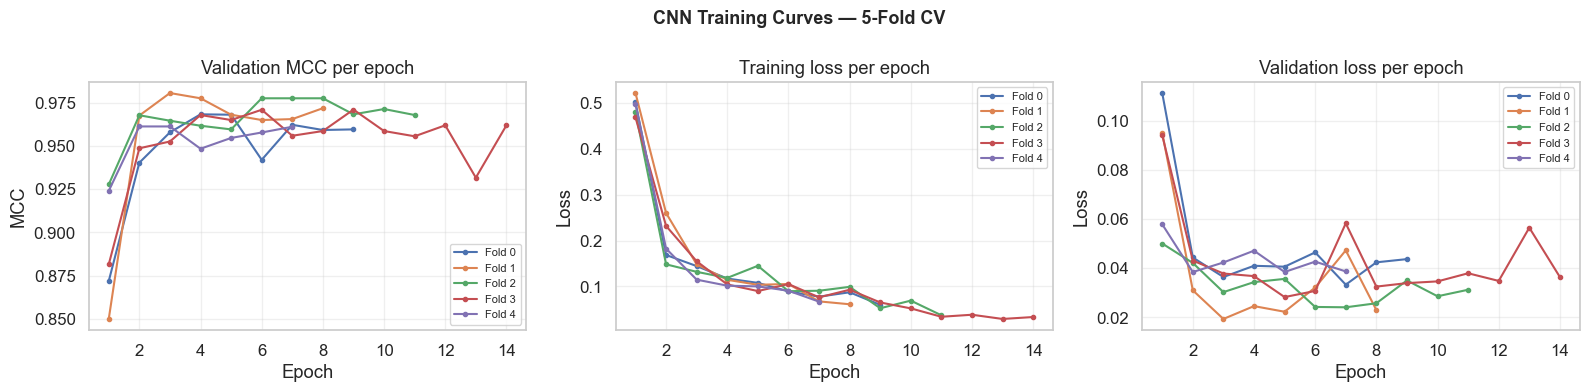

Saved: figures/cnn_training_curves.pdf/.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for fold_id in sorted(history_all['fold'].unique()):
    fold_hist = history_all[history_all['fold'] == fold_id]
    axes[0].plot(fold_hist['epoch'], fold_hist['val_mcc'],    marker='o', ms=3, label=f'Fold {fold_id}')
    axes[1].plot(fold_hist['epoch'], fold_hist['train_loss'], marker='o', ms=3, label=f'Fold {fold_id}')
    axes[2].plot(fold_hist['epoch'], fold_hist['val_loss'],   marker='o', ms=3, label=f'Fold {fold_id}')

axes[0].set_title('Validation MCC per epoch');  axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MCC')
axes[1].set_title('Training loss per epoch');   axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[2].set_title('Validation loss per epoch'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')

for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('CNN Training Curves — 5-Fold CV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/cnn_training_curves.pdf', bbox_inches='tight')
plt.savefig('figures/cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cnn_training_curves.pdf/.png')

---
## Cell 13 — CV metrics bar chart

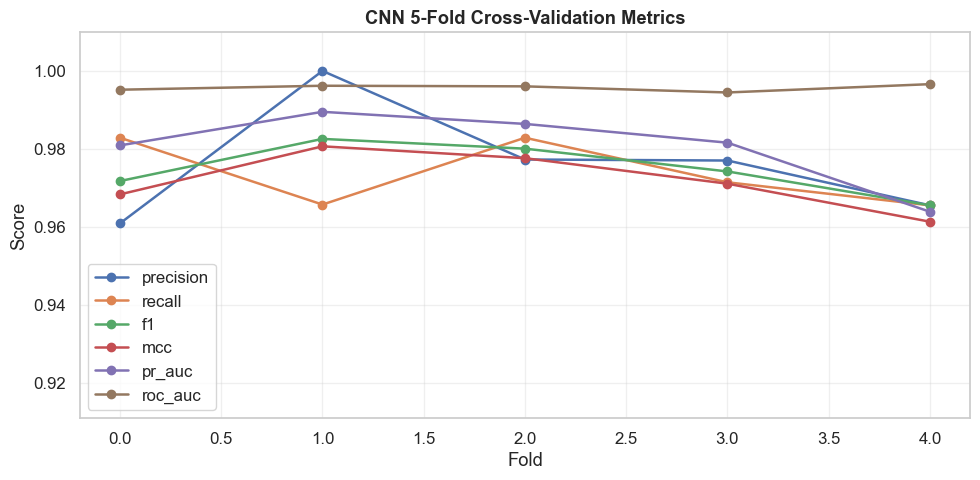

Saved: figures/cnn_cv_metrics.pdf/.png


In [18]:
plt.figure(figsize=(10, 5))
for col in metric_cols:
    plt.plot(cv_results['fold'], cv_results[col], marker='o', linewidth=1.8, label=col)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('CNN 5-Fold Cross-Validation Metrics', fontweight='bold')
plt.legend()
ymin = max(0, cv_results[metric_cols].min().min() - 0.05)
plt.ylim(ymin, 1.01)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/cnn_cv_metrics.pdf', bbox_inches='tight')
plt.savefig('figures/cnn_cv_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cnn_cv_metrics.pdf/.png')

---
## Cell 14 — Train final model on full training set
Retrain on **all** training data using the **average best epoch across CV folds**,
where each fold’s best epoch is defined as the epoch with the highest validation MCC.

This avoids training the final model for too long just because early stopping waited
for additional patience epochs before stopping.
---

In [19]:
# === PRE-COMPUTE ESM-2 EMBEDDINGS FOR BENCHMARK SET (batched for speed) ===
print("Pre-computing ESM-2 embeddings for benchmark set...")

bench_embedding_dict = {}
b_accessions = bench_df['Accession'].tolist()
b_sequences  = [row[:MAX_LEN] for row in bench_df['sequence'].tolist()]

for start in range(0, len(b_sequences), EMBED_BATCH):
    batch_acc  = b_accessions[start : start + EMBED_BATCH]
    batch_seqs = b_sequences [start : start + EMBED_BATCH]
    data = [(acc, seq) for acc, seq in zip(batch_acc, batch_seqs)]

    _, _, batch_tokens = batch_converter(data)
    with torch.no_grad():
        results = esm_model(batch_tokens.to(DEVICE), repr_layers=[12])

    for i, acc in enumerate(batch_acc):
        emb = results["representations"][12][i, 1:-1, :].cpu()
        if emb.shape[0] < MAX_LEN:
            pad = torch.zeros(MAX_LEN - emb.shape[0], ESM_DIM)
            emb = torch.cat([emb, pad], dim=0)
        else:
            emb = emb[:MAX_LEN]
        bench_embedding_dict[acc] = emb

bench_df['embedding'] = bench_df['Accession'].map(bench_embedding_dict)
assert bench_df['embedding'].isna().sum() == 0, "Some benchmark embeddings are missing!"
print(f"✅ Pre-computed embeddings for {len(bench_df):,} benchmark proteins. Ready!")


Pre-computing ESM-2 embeddings for benchmark set...
✅ Pre-computed embeddings for 2,006 benchmark proteins. Ready!


In [20]:
assert 'embedding' in bench_df.columns, "Benchmark embeddings missing — run Cell 32 first"

# === FINAL MODEL TRAINING ON FULL DATASET ===
best_epochs = (
    history_all.loc[history_all.groupby("fold")["val_mcc"].idxmax(), ["fold", "epoch"]]
    .sort_values("fold")
    .reset_index(drop=True)
)

avg_best_epoch = int(round(best_epochs["epoch"].median()))   # median — robust to outlier folds

print("Best epoch per fold:")
print(best_epochs.to_string(index=False))
print()
print(f"Mean best epoch   : {best_epochs['epoch'].mean():.1f}")
print(f"Median best epoch : {best_epochs['epoch'].median():.1f}  ← used for final training")
print(f"Training final model for {avg_best_epoch} epochs on full training set...\n")

full_train_loader = DataLoader(
    ESMSignalPeptideDataset(train_df, max_len=MAX_LEN),
    batch_size=BATCH_SIZE,
    shuffle=True
)
bench_loader = DataLoader(
    ESMSignalPeptideDataset(bench_df, max_len=MAX_LEN),
    batch_size=BATCH_SIZE,
    shuffle=False
)

final_model = SignalCNN(input_dim=ESM_DIM, max_len=MAX_LEN).to(DEVICE)

pos_weight = get_class_pos_weight(train_df["label"].values)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(final_model.parameters(), lr=LR)
# NOTE: CosineAnnealingLR is used here (vs ReduceLROnPlateau in CV) because
# there is no validation set to monitor. The median best epoch from CV
# already accounts for early stopping, so fixed-schedule cosine decay is appropriate.
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=avg_best_epoch, eta_min=LR * 0.1
)

train_losses = []
for epoch in range(1, avg_best_epoch + 1):
    loss = train_one_epoch(final_model, full_train_loader, optimizer, criterion)
    scheduler.step()
    train_losses.append(loss)

    if epoch % 5 == 0 or epoch == avg_best_epoch:
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:02d}/{avg_best_epoch} | loss={loss:.4f} | LR={current_lr:.2e}")

print("\n✅ Final model training complete!")

Best epoch per fold:
 fold  epoch
    0      4
    1      3
    2      6
    3      9
    4      2

Mean best epoch   : 4.8
Median best epoch : 4.0  ← used for final training
Training final model for 4 epochs on full training set...

Epoch 04/4 | loss=0.0659 | LR=1.00e-04

✅ Final model training complete!


---
## Cell 15 — Blind benchmark evaluation

Apply the final model to the benchmark set — sequences the model has **never seen**
during training or CV. This is the unbiased final performance estimate.

In [21]:
bench_logits, bench_true = predict_logits(final_model, bench_loader)
bench_prob    = sigmoid(bench_logits)
bench_metrics = compute_metrics(bench_true, bench_prob)

print('Benchmark Results:')
print('-' * 30)
for k, v in bench_metrics.items():
    if k != 'y_pred':
        print(f'  {k:<12}: {v:.4f}')

print()
print(classification_report(bench_true, bench_metrics['y_pred'],
                             target_names=['SP−', 'SP+'], digits=4))

Benchmark Results:
------------------------------
  precision   : 0.9509
  recall      : 0.9726
  f1          : 0.9616
  mcc         : 0.9569
  pr_auc      : 0.9844
  roc_auc     : 0.9985

              precision    recall  f1-score   support

         SP−     0.9966    0.9938    0.9952      1787
         SP+     0.9509    0.9726    0.9616       219

    accuracy                         0.9915      2006
   macro avg     0.9738    0.9832    0.9784      2006
weighted avg     0.9916    0.9915    0.9916      2006



---
## Cell 16 — Benchmark confusion matrix

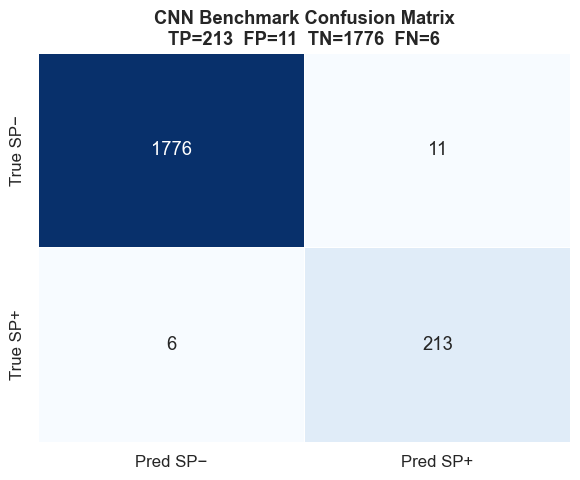

Saved: figures/cnn_benchmark_confusion.pdf/.png


In [22]:
cm = confusion_matrix(bench_true, bench_metrics['y_pred'])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred SP−', 'Pred SP+'],
            yticklabels=['True SP−', 'True SP+'],
            linewidths=0.5, cbar=False)
ax.set_title(f'CNN Benchmark Confusion Matrix\nTP={tp}  FP={fp}  TN={tn}  FN={fn}',
             fontweight='bold')
plt.tight_layout()
plt.savefig('figures/cnn_benchmark_confusion.pdf', bbox_inches='tight')
plt.savefig('figures/cnn_benchmark_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cnn_benchmark_confusion.pdf/.png')

---
## Cell 17 — Benchmark PR and ROC curves

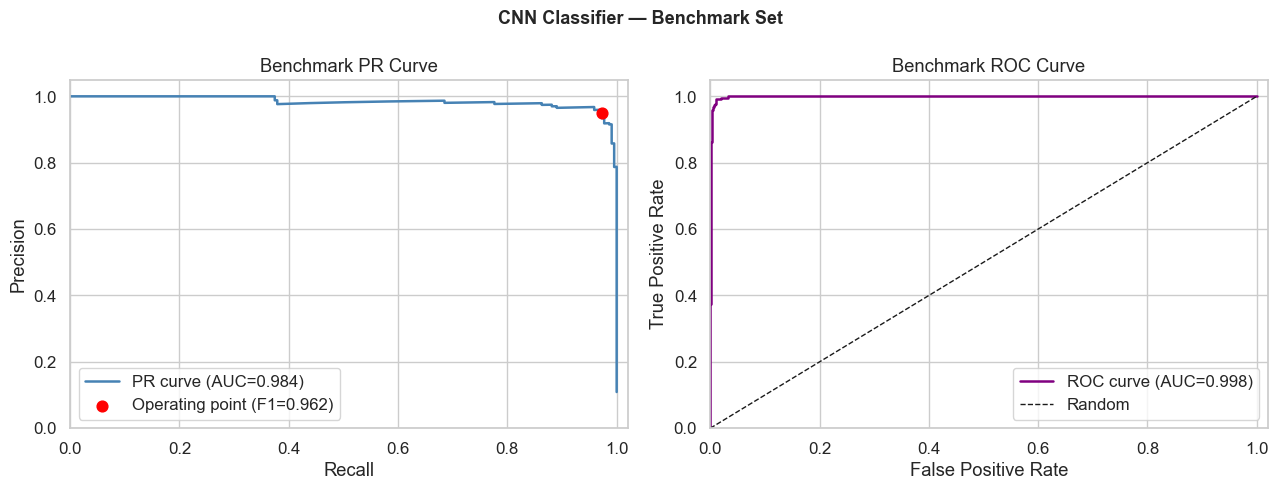

Saved: figures/cnn_benchmark_pr_roc.pdf/.png


In [23]:
precision_curve, recall_curve, _ = precision_recall_curve(bench_true, bench_prob)
fpr, tpr, _ = roc_curve(bench_true, bench_prob)
pr_auc  = average_precision_score(bench_true, bench_prob)
roc_auc = roc_auc_score(bench_true, bench_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recall_curve, precision_curve, color='steelblue', lw=1.8,
             label=f'PR curve (AUC={pr_auc:.3f})')
axes[0].scatter([bench_metrics['recall']], [bench_metrics['precision']],
                color='red', s=60, zorder=5,
                label=f'Operating point (F1={bench_metrics["f1"]:.3f})')
axes[0].set_xlabel('Recall');  axes[0].set_ylabel('Precision')
axes[0].set_title('Benchmark PR Curve'); axes[0].legend()
axes[0].set_xlim(0, 1.02); axes[0].set_ylim(0, 1.05)

axes[1].plot(fpr, tpr, color='purple', lw=1.8, label=f'ROC curve (AUC={roc_auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Benchmark ROC Curve'); axes[1].legend()
axes[1].set_xlim(0, 1.02); axes[1].set_ylim(0, 1.05)

plt.suptitle('CNN Classifier — Benchmark Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/cnn_benchmark_pr_roc.pdf', bbox_inches='tight')
plt.savefig('figures/cnn_benchmark_pr_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cnn_benchmark_pr_roc.pdf/.png')

---
## Cell 18 — Full model comparison table
This table compares the models on the **benchmark set** using point metrics derived from final predictions:
**Precision, Recall, F1, and MCC**.

The PR AUC and ROC AUC values available for Von Heijne and SVM come from **5-fold OOF cross-validation**, not from the benchmark set, so they are reported separately to avoid mixing evaluation settings.
---

In [24]:
# === BENCHMARK-SET COMPARISON TABLE ===
# Use SVM "All features (28)" because it performs better than the selected-feature version
# on the benchmark set and matches the OOF CV plots shown in Step 5.

VH_METRICS = {
    "Precision": 0.6255,
    "Recall": 0.7169,
    "F1": 0.6681,
    "MCC": 0.6261
}

SVM_METRICS = {
    "Precision": 0.8716,
    "Recall": 0.8676,
    "F1": 0.8696,
    "MCC": 0.8536
}

CNN_METRICS = {
    "Precision": bench_metrics["precision"],
    "Recall": bench_metrics["recall"],
    "F1": bench_metrics["f1"],
    "MCC": bench_metrics["mcc"]
}

comparison_df = pd.DataFrame([
    {"Model": "Von Heijne", **VH_METRICS},
    {"Model": "SVM (All features, 28)", **SVM_METRICS},
    {"Model": "CNN + BiLSTM (ESM-2)", **CNN_METRICS}
])

display(comparison_df.round(4))

,Model,Precision,Recall,F1,MCC
0,Von Heijne,0.6255,0.7169,0.6681,0.6261
1,"SVM (All features, 28)",0.8716,0.8676,0.8696,0.8536
2,CNN + BiLSTM (ESM-2),0.9509,0.9726,0.9616,0.9569


---
## Cell 19 — Save all outputs

In [25]:
torch.save(final_model.state_dict(), 'cnn_signal_peptide_model.pt')
cv_results.to_csv('cnn_cv_results.tsv',        sep='\t', index=False)
comparison_df.to_csv('cnn_model_comparison.tsv', sep='\t', index=False)
history_all.to_csv('cnn_training_history.tsv',  sep='\t', index=False)

print('Saved:')
print('  cnn_signal_peptide_model.pt  — final model weights')
print('  cnn_cv_results.tsv           — per-fold CV metrics')
print('  cnn_model_comparison.tsv     — all models compared')
print('  cnn_training_history.tsv     — per-epoch training log')
print()
print('Figures saved to figures/cnn_*.pdf and figures/cnn_*.png')

Saved:
  cnn_signal_peptide_model.pt  — final model weights
  cnn_cv_results.tsv           — per-fold CV metrics
  cnn_model_comparison.tsv     — all models compared
  cnn_training_history.tsv     — per-epoch training log

Figures saved to figures/cnn_*.pdf and figures/cnn_*.png


---
## Cell 20 — Final summary

In [26]:
sep = '=' * 62
print(sep)
print('  CNN CLASSIFIER SUMMARY — LB2 Group 7')
print(sep)
print()
print('  Architecture')
print(f'    Input window   : {MAX_LEN} aa (N-terminal)')
print('    Conv blocks    : 3 × (Conv1d → ReLU → BatchNorm); MaxPool after blocks 1 and 2 only')
print('    LSTM           : 2-layer bidirectional (hidden=128)')
print('    Filters        : 64 / 128 / 128')
print('    Kernel sizes   : 3 / 5 / 3')
print(f'    Dropout        : {DROPOUT}')
print(f'    Parameters     : {sum(p.numel() for p in final_model.parameters()):,}')
print()
print('  Training')
print(f'    Optimizer      : Adam (LR={LR})')
print(f'    LR scheduler   : ReduceLROnPlateau (factor={LR_FACTOR}, patience={LR_PATIENCE})')
print(f'    Loss           : BCEWithLogitsLoss (class-weighted)')
print(f'    Early stopping : patience={PATIENCE} (tracked on val MCC)')
print(f'    Final epochs   : {avg_best_epoch} (median of CV best epochs)')
print()
print(f'  {"Metric":<12} {"CV Mean":>10} {"CV Std":>10} {"Benchmark":>12}')
print('  ' + '-' * 46)
for col in ['mcc', 'f1', 'precision', 'recall', 'roc_auc', 'pr_auc']:
    print(f'  {col:<12} {cv_results[col].mean():>10.4f} {cv_results[col].std():>10.4f} {bench_metrics[col]:>12.4f}')
print()
print(sep)

  CNN CLASSIFIER SUMMARY — LB2 Group 7

  Architecture
    Input window   : 150 aa (N-terminal)
    Conv blocks    : 3 × (Conv1d → ReLU → BatchNorm); MaxPool after blocks 1 and 2 only
    LSTM           : 2-layer bidirectional (hidden=128)
    Filters        : 64 / 128 / 128
    Kernel sizes   : 3 / 5 / 3
    Dropout        : 0.3
    Parameters     : 875,713

  Training
    Optimizer      : Adam (LR=0.001)
    LR scheduler   : ReduceLROnPlateau (factor=0.5, patience=3)
    Loss           : BCEWithLogitsLoss (class-weighted)
    Early stopping : patience=5 (tracked on val MCC)
    Final epochs   : 4 (median of CV best epochs)

  Metric          CV Mean     CV Std    Benchmark
  ----------------------------------------------
  mcc              0.9718     0.0077       0.9569
  f1               0.9748     0.0068       0.9616
  precision        0.9761     0.0151       0.9509
  recall           0.9737     0.0087       0.9726
  roc_auc          0.9957     0.0009       0.9985
  pr_auc         